# Two-Scale FPN ResNet Object Detector

Trains `MultiScaleObjectDetectorResNet` with fine (`28 x 28`) and medium (`14 x 14`) detection heads. Each scale predicts three anchor slots with `[x, y, w, h, conf, class_logits...]`; ground-truth boxes are routed to the scale and anchor with the strongest shape IoU.

**Pipeline:**
`get_detection_loaders` -> `MultiScaleObjectDetectorResNet` -> `DetectionLoss` (Focal Loss) -> `fit()`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import (
    YOLO_ANCHORS_PER_SCALE,
    YOLO_GRID_SIZES,
    get_detection_loaders,
)
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_multiscale_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
GRID_SIZES  = YOLO_GRID_SIZES
CONF_THRESH = 0.5
MODEL_SIZE  = 'n'
CLASS_NAMES = EMNIST_CLASS_NAMES['bymerge']
ANCHORS_PER_SCALE = YOLO_ANCHORS_PER_SCALE
USE_FOCAL_LOSS = True
FOCAL_ALPHA    = 0.25
FOCAL_GAMMA    = 2.0
USE_POS_WEIGHT = False


def flatten_detection_grids(grids):
    """Flatten one- or multi-scale prediction/target grids to (B, N, D)."""
    if isinstance(grids, dict):
        return torch.cat(
            [grid.reshape(grid.size(0), -1, grid.size(-1)) for grid in grids.values()],
            dim=1,
        )
    return grids.reshape(grids.size(0), -1, grids.size(-1))


print(f'Device      : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
print(f'Grid sizes  : {GRID_SIZES}')
print(f'Anchors/head: {ANCHORS_PER_SCALE}')

Device      : cuda
PyTorch     : 2.11.0+cu130
Grid sizes  : (28, 14)
Anchors/head: 3


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size=BATCH_SIZE,
    test=True,
    grid_sizes=GRID_SIZES,
    anchors_per_scale=ANCHORS_PER_SCALE,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
imgs, targets, labels = next(iter(train_loader))

print(f'Image batch shape: {imgs.shape}')
for grid_size in GRID_SIZES:
    print(
        f'Grid {grid_size:>2} targets: {targets[grid_size].shape} | '
        f'labels: {labels[grid_size].shape}'
    )
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Image batch shape: torch.Size([198, 1, 224, 224])
Grid 28 targets: torch.Size([198, 28, 28, 3, 5]) | labels: torch.Size([198, 28, 28, 3])
Grid 14 targets: torch.Size([198, 14, 14, 3, 5]) | labels: torch.Size([198, 14, 14, 3])
Train batches: 1213 | Val batches: 76


## 2 · Model Architecture


In [3]:
model = get_multiscale_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    outputs_by_scale = model(imgs.to(DEVICE))

for grid_size in GRID_SIZES:
    print(f'Grid {grid_size:>2} output: {outputs_by_scale[grid_size].shape}')

Parameters: 488,408
Grid 28 output: torch.Size([198, 28, 28, 3, 52])
Grid 14 output: torch.Size([198, 14, 14, 3, 52])


## 3 · Loss Function, Optimiser & Scheduler


In [4]:
criterion = DetectionLoss(
    lambda_conf    = 1.0,
    lambda_class   = 1.0,
    lambda_iou     = 1.0,
    use_focal_loss = USE_FOCAL_LOSS,
    focal_alpha    = FOCAL_ALPHA,
    focal_gamma    = FOCAL_GAMMA,
    use_pos_weight = USE_POS_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
)

scale_tag = 'x'.join(map(str, GRID_SIZES))
NAME = f'two_scale_{scale_tag}_{ANCHORS_PER_SCALE}a_detector_{MODEL_SIZE}'
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f'../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../checkpoint/{NAME}_best.pth',
    mode='max',
)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')
print(f'Run name  : {NAME}')

Criterion : DetectionLoss
Optimizer : AdamW
Scheduler : OneCycleLR
Run name  : two_scale_28x14_3a_detector_n


## 4 · Training


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run 'two_scale_28x14_3a_detector_n_20260918_084810' started — saving to 'C:\OD-From-Scratch\logs\MultiScaleObjectDetectorResNet\two_scale_28x14_3a_detector_n_20260918_084810.json'
Resuming training from epoch 58
Batch  1 | data=841.4ms pad=1.7ms forward=213.2ms loss=291.7ms backward=514.2ms step=198.0ms
Batch  2 | data=0.2ms pad=1.1ms forward=10.3ms loss=14.8ms backward=31.1ms step=2.4ms
Batch  3 | data=0.2ms pad=1.0ms forward=10.0ms loss=5.2ms backward=29.4ms step=8.2ms
Batch  4 | data=0.2ms pad=1.0ms forward=10.0ms loss=5.3ms backward=30.9ms step=3.8ms
Batch  5 | data=0.2ms pad=1.0ms forward=10.1ms loss=4.6ms backward=30.9ms step=3.8ms
Train: 95.0s | Val: 44.5s
  --> Det  | PR: 0.727 | Rec: 0.121 | F1: 0.207 | TP: 14467 FP: 5442 FN: 105438
  --> Cls  | Acc: 0.834
  --> E2E  | F1: 0.173 | PR: 0.606 | Rec: 0.101
[RunLogger] Epoch  59 | train_loss=2.0448  val_loss=2.3127  val_f1=0.1727%  lr=1.40e-06  ⏱ 95.0s  ★ NEW BEST
Batch  1 | 

## 5 · Training Dashboard & Curves


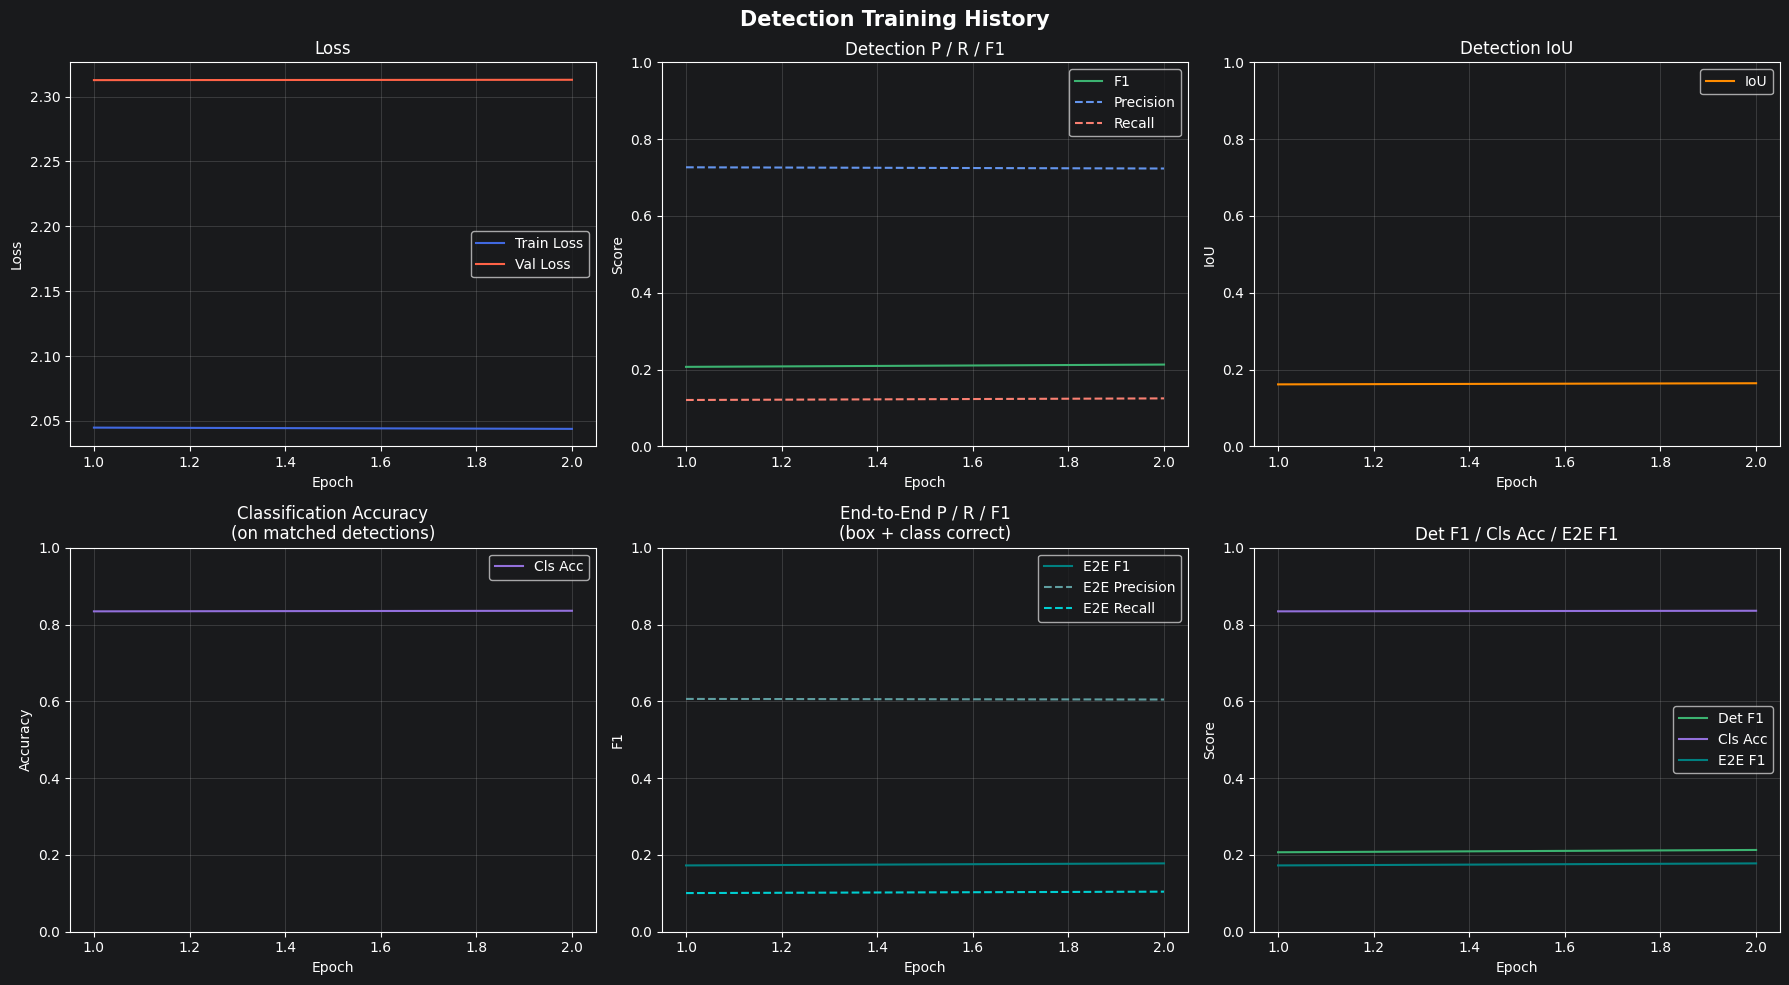

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 6 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 2.8488
  IoU      : 0.1655
  Precision: 0.6002
  Recall   : 0.1714
  F1       : 0.2667
  TP/FP/FN : 61803 / 41175 / 298764

=== Classification (on matched detections) ===
  Accuracy : 0.8183
  Per-class:
    [0] class_0: acc=0.4848  e2e_p=0.4262  e2e_r=0.0454  e2e_f1=0.0821
    [1] class_1: acc=0.3499  e2e_p=0.4121  e2e_r=0.1792  e2e_f1=0.2498
    [2] class_2: acc=0.8250  e2e_p=0.5262  e2e_r=0.0673  e2e_f1=0.1193
    [3] class_3: acc=0.9466  e2e_p=0.6373  e2e_r=0.1306  e2e_f1=0.2168
    [4] class_4: acc=0.8649  e2e_p=0.5623  e2e_r=0.0995  e2e_f1=0.1691
    [5] class_5: acc=0.8199  e2e_p=0.5744  e2e_r=0.0916  e2e_f1=0.1580
    [6] class_6: acc=0.8705  e2e_p=0.5860  e2e_r=0.1791  e2e_f1=0.2743
    [7] class_7: acc=0.9688  e2e_p=0.5698  e2e_r=0.1524  e2e_f1=0.2405
    [8] class_8: acc=0.9174  e2e_p=0.5468  e2e_r=0.1496  e2e_f1=0.2350
    [9] class_9: acc=0.7415  e2e_p=0.4393  e2e_r=0.2332  e2e_f1=0.3046
    [10] class_10: acc=0.9645  e2e_p=0.5

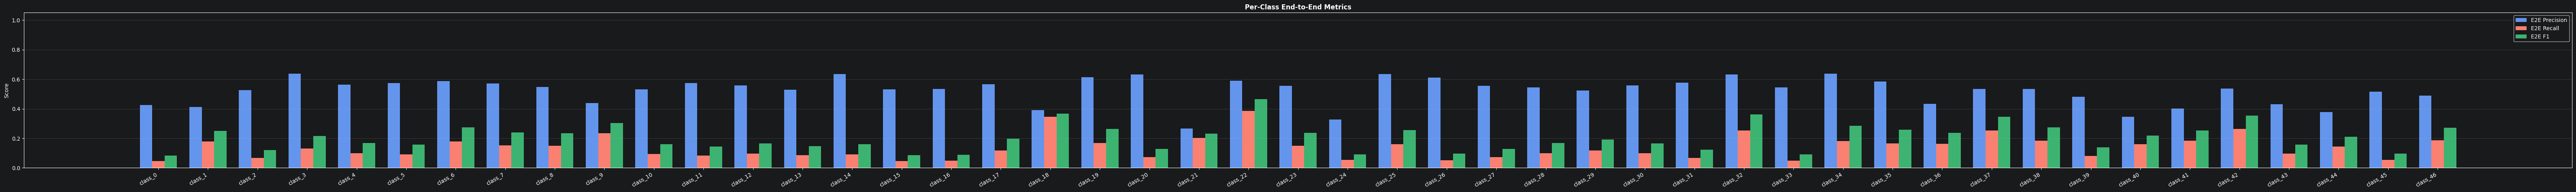

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 7 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH` (plus NMS)


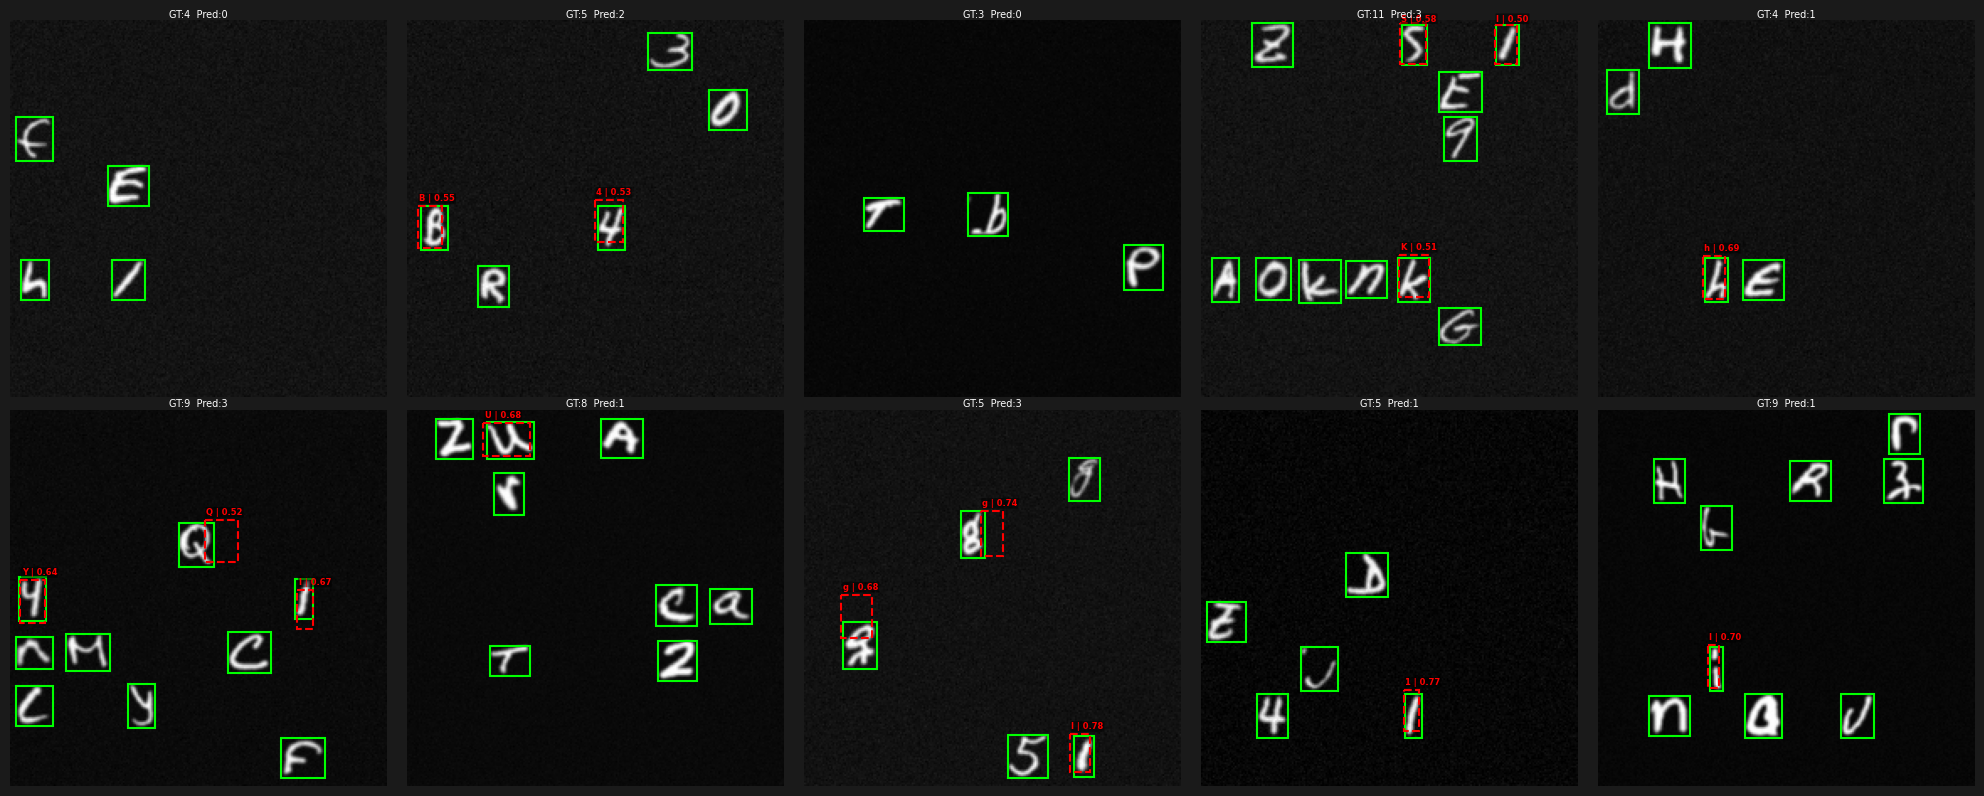

In [9]:
imgs_t, targets_t, _ = next(iter(test_loader))
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE))

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=flatten_detection_grids(preds_t).cpu(),
    gt_grid=flatten_detection_grids(targets_t),
    conf_thresh=CONF_THRESH,
    class_names=CLASS_NAMES,
)

## 8 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to evaluate the full Precision / Recall / F1 trade-off.


In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.1257  0.8212  0.2180   0.8507   296114  2060439    64453
  0.15  0.1666  0.8130  0.2766   0.8521   293136  1466121    67431
  0.20  0.2197  0.7999  0.3447   0.8531   288432  1024527    72135
  0.25  0.2837  0.7767  0.4156   0.8536   280053   706956    80514
  0.30  0.3764  0.7005  0.4897   0.8527   252595   418512   107972
  0.35  0.4731  0.5253  0.4978   0.8498   189394   210892   171173
  0.40  0.5213  0.3558  0.4229   0.8427   128279   117815   232288
  0.45  0.5532  0.2480  0.3425   0.8324    89421    72233   271146
  0.50  0.6002  0.1714  0.2667   0.8183    61803    41175   298764
  0.55  0.6438  0.1244  0.2085   0.8045    44862    24822   315705
  0.60  0.6822  0.0901  0.1591   0.7912    32481    15133   328086
  0.65  0.7019  0.0617  0.1134   0.7777    22244     9449   338323
  0.70  0.7044  0.0367  0.0698   0.7671    13248     5560   3

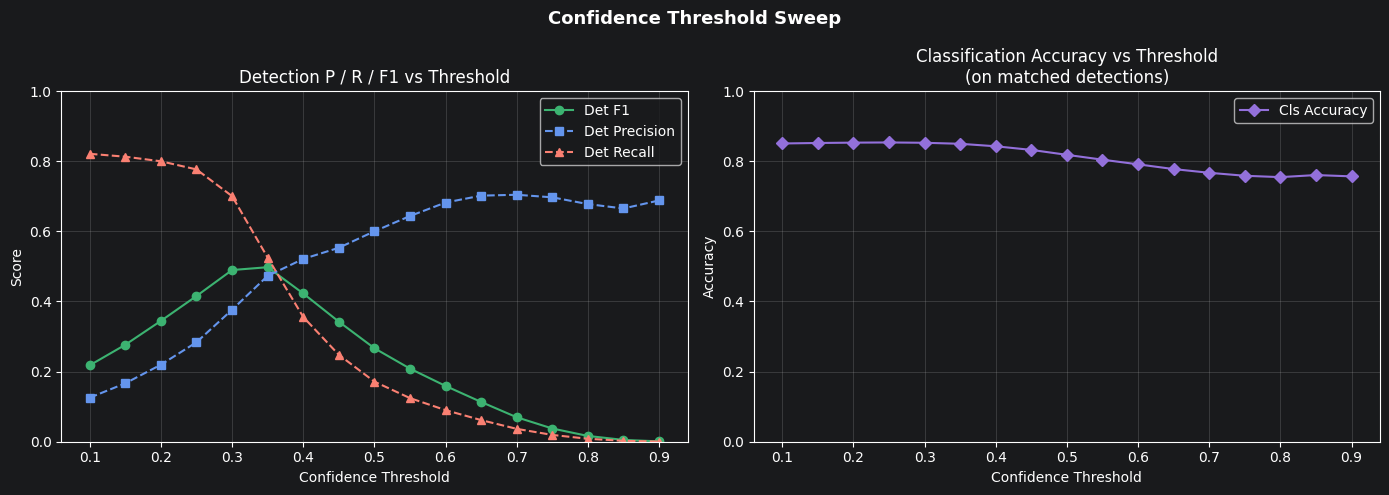


Best conf threshold : 0.35
  Det  F1  = 0.4978
  Cls  Acc = 0.8498
Per-class E2E F1:
  [0] class_0: e2e_f1=0.3197  e2e_p=0.3216  e2e_r=0.3178
  [1] class_1: e2e_f1=0.2909  e2e_p=0.3199  e2e_r=0.2668
  [2] class_2: e2e_f1=0.4734  e2e_p=0.4474  e2e_r=0.5025
  [3] class_3: e2e_f1=0.5258  e2e_p=0.5346  e2e_r=0.5172
  [4] class_4: e2e_f1=0.4317  e2e_p=0.4872  e2e_r=0.3876
  [5] class_5: e2e_f1=0.4404  e2e_p=0.4645  e2e_r=0.4187
  [6] class_6: e2e_f1=0.5112  e2e_p=0.4654  e2e_r=0.5670
  [7] class_7: e2e_f1=0.5077  e2e_p=0.4554  e2e_r=0.5735
  [8] class_8: e2e_f1=0.4575  e2e_p=0.4419  e2e_r=0.4742
  [9] class_9: e2e_f1=0.3921  e2e_p=0.3066  e2e_r=0.5435
  [10] class_10: e2e_f1=0.4358  e2e_p=0.4678  e2e_r=0.4079
  [11] class_11: e2e_f1=0.4794  e2e_p=0.5050  e2e_r=0.4564
  [12] class_12: e2e_f1=0.5384  e2e_p=0.4582  e2e_r=0.6526
  [13] class_13: e2e_f1=0.4994  e2e_p=0.4569  e2e_r=0.5506
  [14] class_14: e2e_f1=0.4506  e2e_p=0.5156  e2e_r=0.4002
  [15] class_15: e2e_f1=0.2316  e2e_p=0.3882  e2e

In [11]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
